In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

def plot_clusters(X, y_pred, title):
    plt.figure(figsize=(6, 4))
    
    # 1. Isolate the regular clusters (everything that is NOT -1)
    cluster_mask = y_pred != -1
    plt.scatter(X[cluster_mask, 0], X[cluster_mask, 1], 
                c=y_pred[cluster_mask], cmap='plasma', 
                edgecolor='black', s=50, alpha=0.8)
    
    # 2. Isolate and plot the noise points (DBSCAN's -1 labels)
    noise_mask = y_pred == -1
    if np.any(noise_mask):
        plt.scatter(X[noise_mask, 0], X[noise_mask, 1], 
                    color='black', marker='x', s=30, alpha=0.6, label='Noise')
        plt.legend()
        
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- GENERATE DATASETS ---
# Dataset 1: Simple Blobs
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42) #cluster_std = 1.5

# Dataset 2: Non-spherical Moons
X_shapes, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# Part 3: Clustering (Finding Hidden Groups)
In unsupervised learning, we don't have labels (no `y`). We just have raw data, and we ask the algorithm to find structures. 
The biggest challenge? **Hyperparameters.** The algorithm doesn't know the truth, so if we give it the wrong parameters, it will force the data into the wrong shapes.

## 1. K-Means and the "k" Hyperparameter
K-Means looks for spherical centers. Let's see what happens when we guess the number of clusters (`n_clusters`) incorrectly on a very simple dataset.

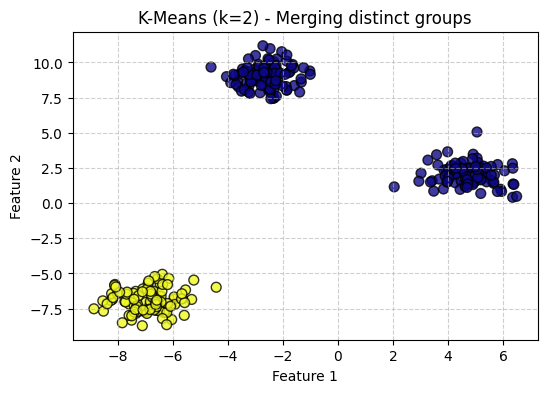

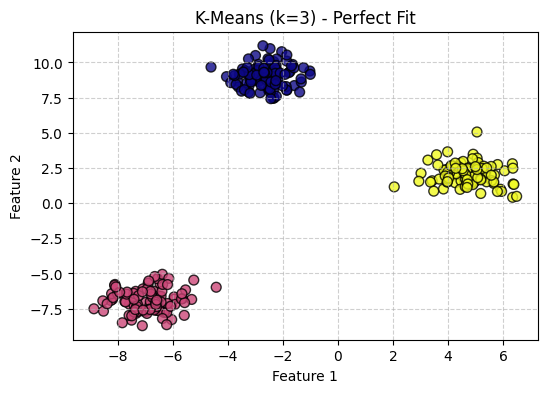

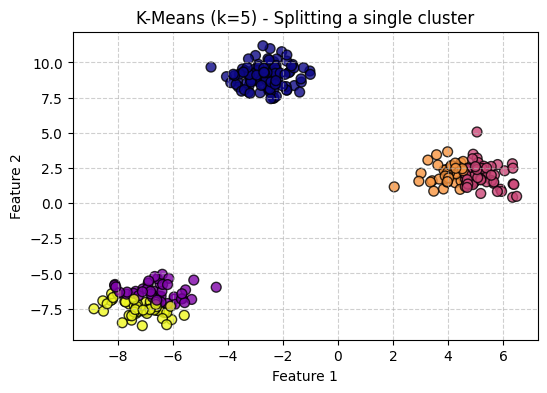

In [21]:
# K-Means guessing 2 clusters (Under-segmenting)
kmeans_2 = KMeans(n_clusters = 2, random_state = 42)
pred_2 = kmeans_2.fit_predict(X_blobs)
plot_clusters(X_blobs, preds_2, "K-Means (k=2) - Merging distinct groups")

# K-Means guessing 3 clusters (The true number)
kmeans_3 = KMeans(n_clusters = 3, random_state = 42)
pred_3 = kmeans_3.fit_predict(X_blobs)
plot_clusters(X_blobs, preds_3, "K-Means (k=3) - Perfect Fit")

# K-Means guessing 5 clusters (Over-segmenting)
kmeans_5 = KMeans(n_clusters = 5, random_state = 42)
pred_5 = kmeans_5.fit_predict(X_blobs)
plot_clusters(X_blobs, preds_5, "K-Means (k=5) - Splitting a single cluster")

## 2. The Shape Problem: K-Means vs Hierarchical
Real-world data isn't always spherical. What if our data forms contiguous lines or curves? Let's apply K-Means and Agglomerative (Hierarchical) Clustering to our crescent moon dataset.

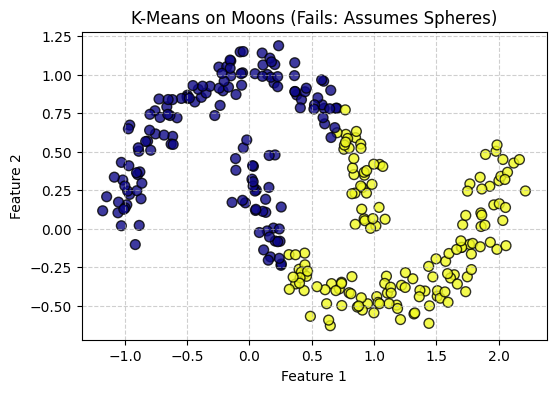

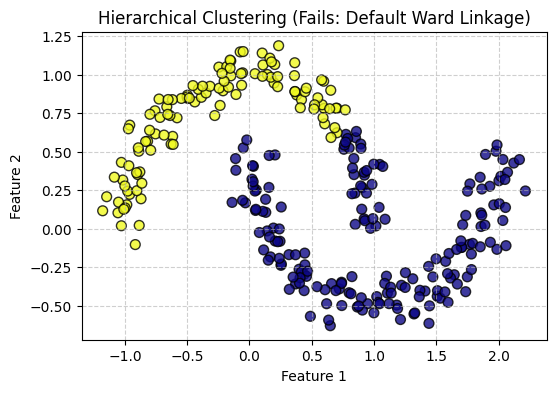

In [23]:
# Watch K-Means fail (it cuts the curves in half because it builds circular boundaries)
kmeans_shapes = KMeans(n_clusters = 2, random_state = 42)
preds_kmeans_shapes = kmeans_shapes.fit_predict(X_shapes)
plot_clusters(X_shapes, preds_kmeans_shapes, "K-Means on Moons (Fails: Assumes Spheres)")

# Watch Hierarchical (Agglomerative) fail with default settings (Ward linkage)
hierarchical = AgglomerativeClustering(n_clusters = 2)
preds_hierarchical = hierarchical.fit_predict(X_shapes)
plot_clusters(X_shapes, preds_hierarchical, "Hierarchical Clustering (Fails: Default Ward Linkage)")

## 3. Density-Based Rescue: DBSCAN
DBSCAN doesn't care about centers or spheres. It just looks for dense continuous regions. 
However, it is highly sensitive to the `eps` hyperparameter (the search radius around each point). Let's tune it! *(Note: Black dots represent anomalies/noise)*.

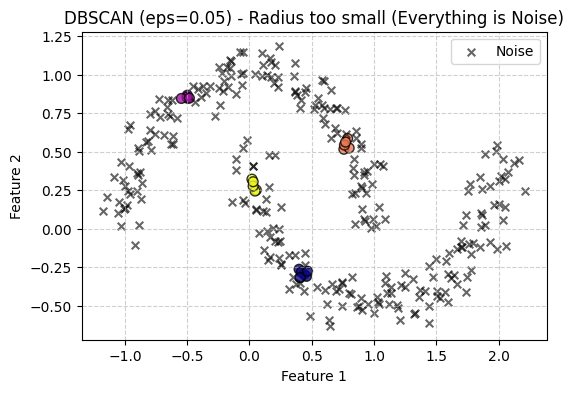

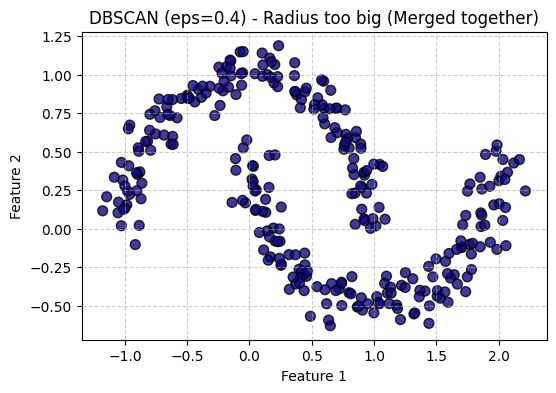

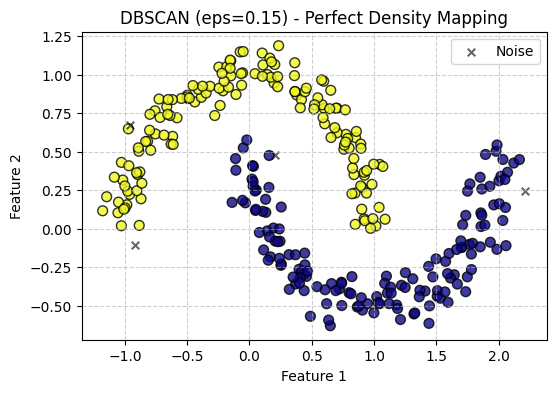

In [25]:
# 1. Radius too small: Everything is disconnected, so it classifies almost everything as noise (Black)
dbscan_small = DBSCAN(eps = 0.05, min_samples = 5)
preds_db_small = dbscan_small.fit_predict(X_shapes)
plot_clusters(X_shapes, preds_db_small, "DBSCAN (eps=0.05) - Radius too small (Everything is Noise)")

# 2. Radius too big: The radius reaches across the gap, merging everything into one giant cluster
dbscan_big = DBSCAN(eps = 0.4, min_samples = 5)
preds_db_big = dbscan_big.fit_predict(X_shapes)
plot_clusters(X_shapes, preds_db_big, "DBSCAN (eps=0.4) - Radius too big (Merged together)")

# 3. Radius just right: Perfect topological mapping of the shapes!
dbscan_perfect = DBSCAN(eps = 0.15, min_samples = 5)
preds_db_perfect = dbscan_perfect.fit_predict(X_shapes)
plot_clusters(X_shapes, preds_db_perfect, "DBSCAN (eps=0.15) - Perfect Density Mapping")